In [145]:
from pathlib import Path

import pandas as pd
import requests

# Replace with your own key from https://www.alphavantage.co/support/#api-key
api_key = "QN74SBYS8NBPJBZP"
target_ticker = "GOOG"  # Change this value to fetch another ticker

base_url = "https://www.alphavantage.co/query"
params = {
    "function": "NEWS_SENTIMENT",
    "tickers": target_ticker,
    "time_from": "20230101T0130",
    "time_to": "20241231T0130",
    "limit": 1000,
    "apikey": api_key,
}

r = requests.get(base_url, params=params, timeout=30)
data = r.json()

rows = []
for item in data.get("feed", []):
    ticker_sentiment = next(
        (
            ts
            for ts in item.get("ticker_sentiment", [])
            if ts.get("ticker") == target_ticker
        ),
        None,
    )

    if ticker_sentiment is None:
        continue

    published_raw = item.get("time_published", "")
    published_date = pd.to_datetime(
        published_raw, format="%Y%m%dT%H%M%S", errors="coerce"
    )
    published_date = published_date.strftime("%Y-%m-%d") if pd.notna(published_date) else ""

    rows.append(
        {
            "ticker": target_ticker,
            "title": item.get("title", ""),
            "time_published": published_date,
            "summary": item.get("summary", ""),
            "category_within_source": item.get("category_within_source", ""),
            "overall_sentiment_score": item.get("overall_sentiment_score", ""),
            "overall_sentiment_label": item.get("overall_sentiment_label", ""),
            "ticker_sentiment_score": ticker_sentiment.get("ticker_sentiment_score", ""),
            "ticker_sentiment_label": ticker_sentiment.get("ticker_sentiment_label", ""),
        }
    )

new_df = pd.DataFrame(
    rows,
    columns=[
        "ticker",
        "title",
        "time_published",
        "summary",
        "category_within_source",
        "overall_sentiment_score",
        "overall_sentiment_label",
        "ticker_sentiment_score",
        "ticker_sentiment_label",
    ],
)

output_dir = Path("../data/news_data")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "news_sentiment.csv"

if output_path.exists():
    existing_df = pd.read_csv(output_path)
else:
    existing_df = pd.DataFrame(columns=new_df.columns)

combined_df = pd.concat([existing_df, new_df], ignore_index=True)
combined_df = combined_df.drop_duplicates(subset=["ticker", "title", "time_published"], keep="last")
combined_df.to_csv(output_path, index=False)

inserted_rows = len(combined_df) - len(existing_df)
print(f"Fetched {len(new_df)} rows for {target_ticker}")
print(f"Inserted {inserted_rows} new rows into {output_path}")
print(f"Total rows in table: {len(combined_df)}")
combined_df.tail()

Fetched 491 rows for GOOG
Inserted 197 new rows into ../data/news_data/news_sentiment.csv
Total rows in table: 5084


,ticker,title,time_published,summary,category_within_source,overall_sentiment_score,overall_sentiment_label,ticker_sentiment_score,ticker_sentiment_label
5373,GOOG,Getty Images suing the makers of popular AI ar...,2023-01-18,Getty Images has filed a lawsuit against Stabi...,General,0.003945,Neutral,0.145776,Neutral
5374,GOOG,Take a Global View with This ETF,2023-01-18,The iShares Global Comm Services ETF (IXP) off...,General,0.169928,Somewhat-Bullish,0.155881,Somewhat-Bullish
5375,GOOG,Families joined in lawsuit targeting social me...,2023-01-14,Over 100 families have joined a consolidated l...,General,-0.372735,Bearish,-0.315082,Somewhat-Bearish
5376,GOOG,Meta faces a future of more legal woes and fal...,2023-01-12,"Meta, formerly Facebook, is experiencing signi...",General,-0.273325,Somewhat-Bearish,-0.194100,Somewhat-Bearish
5377,GOOG,Baidu Research Unveils Top 10 Tech Trends for ...,2023-01-05,Baidu Research has released its predictions fo...,General,0.337176,Somewhat-Bullish,0.347278,Somewhat-Bullish


In [146]:
from pathlib import Path

import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, f1_score
from xgboost import XGBClassifier

feature_path = Path("../data/news_data/news_sentiment_transformer_features.csv")
metrics_path = Path("../data/news_data/xgboost_classification_metrics.csv")
predictions_path = Path("../data/news_data/xgboost_classification_predictions.csv")

target_column = "ticker_sentiment_label"
ticker_filter = None  # Set to a ticker like "IBM" to train on a single ticker only.
validation_fraction = 0.2
early_stopping_rounds = 30

In [147]:
df = pd.read_csv(feature_path)

if ticker_filter is not None:
    df = df[df["ticker"] == ticker_filter].copy()

df["time_published"] = pd.to_datetime(df["time_published"], errors="coerce")
df[target_column] = df[target_column].astype(str).str.strip()
df = df.dropna(subset=["time_published", target_column]).sort_values("time_published").reset_index(drop=True)

embedding_columns = [column for column in df.columns if column.startswith("text_emb_")]
if not embedding_columns:
    raise ValueError("No transformer embedding columns were found in the feature table.")

# Remove rows with empty labels after cleaning.
df = df[df[target_column] != ""]
label_counts = df[target_column].value_counts()
valid_labels = label_counts[label_counts >= 2].index
df = df[df[target_column].isin(valid_labels)].copy()

if df[target_column].nunique() < 2:
    raise ValueError("Need at least two classes with at least 2 samples each for classification.")

split_index = max(int(len(df) * 0.8), 1)
split_index = min(split_index, len(df) - 1)

if split_index <= 1:
    raise ValueError("Not enough rows to create train/test sets.")

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

validation_size = max(int(len(train_df) * validation_fraction), 1)
validation_size = min(validation_size, len(train_df) - 1)

if validation_size <= 0:
    raise ValueError("Not enough training rows to create a validation split.")

subtrain_df = train_df.iloc[:-validation_size].copy()
valid_df = train_df.iloc[-validation_size:].copy()

X_subtrain = subtrain_df[embedding_columns]
y_subtrain = subtrain_df[target_column]
X_valid = valid_df[embedding_columns]
y_valid = valid_df[target_column]
X_train = train_df[embedding_columns]
y_train = train_df[target_column]
X_test = test_df[embedding_columns]
y_test = test_df[target_column]

class_names = sorted(df[target_column].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
int_to_label = {i: label for label, i in label_to_int.items()}
y_subtrain_encoded = y_subtrain.map(label_to_int)
y_valid_encoded = y_valid.map(label_to_int)
y_train_encoded = y_train.map(label_to_int)
y_test_encoded = y_test.map(label_to_int)

print(f"Rows: {len(df)}")
print(f"Embedding features: {len(embedding_columns)}")
print(f"Classes: {class_names}")
print(
    f"Subtrain rows: {len(subtrain_df)} | Validation rows: {len(valid_df)} | Test rows: {len(test_df)}"
)
print(f"Train date range: {train_df['time_published'].min().date()} to {train_df['time_published'].max().date()}")
print(f"Validation date range: {valid_df['time_published'].min().date()} to {valid_df['time_published'].max().date()}")
print(f"Test date range: {test_df['time_published'].min().date()} to {test_df['time_published'].max().date()}")

Rows: 5084
Embedding features: 768
Classes: ['Bearish', 'Bullish', 'Neutral', 'Somewhat-Bearish', 'Somewhat-Bullish']
Subtrain rows: 3254 | Validation rows: 813 | Test rows: 1017
Train date range: 2023-01-05 to 2026-02-25
Validation date range: 2026-01-25 to 2026-02-25
Test date range: 2026-02-25 to 2026-04-17


In [148]:
model = XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=early_stopping_rounds,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_subtrain,
    y_subtrain_encoded,
    eval_set=[(X_valid, y_valid_encoded)],
    verbose=False,
)

train_predictions_encoded = model.predict(X_train)
train_predictions = pd.Series(train_predictions_encoded).map(int_to_label).values

valid_predictions_encoded = model.predict(X_valid)
valid_predictions = pd.Series(valid_predictions_encoded).map(int_to_label).values

test_predictions_encoded = model.predict(X_test)
test_predictions = pd.Series(test_predictions_encoded).map(int_to_label).values

metrics = {
    "best_iteration": model.best_iteration if model.best_iteration is not None else model.n_estimators,
    "train accuracy": accuracy_score(y_train, train_predictions),
    "train f1_weighted": f1_score(y_train, train_predictions, average="weighted"),
    "train f1_macro": f1_score(y_train, train_predictions, average="macro"),
    "validation accuracy": accuracy_score(y_valid, valid_predictions),
    "validation f1_weighted": f1_score(y_valid, valid_predictions, average="weighted"),
    "validation f1_macro": f1_score(y_valid, valid_predictions, average="macro"),
    "test accuracy": accuracy_score(y_test, test_predictions),
    "test f1_weighted": f1_score(y_test, test_predictions, average="weighted"),
    "test f1_macro": f1_score(y_test, test_predictions, average="macro"),
}

metrics_df = pd.DataFrame(
    [
        {
            "run_time": pd.Timestamp.now().isoformat(),
            "ticker_filter": ticker_filter or "ALL",
            "subtrain_rows": len(subtrain_df),
            "validation_rows": len(valid_df),
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "feature_count": len(embedding_columns),
            "class_count": len(class_names),
            **metrics,
        }
    ]
)

report = classification_report(y_test, test_predictions,labels=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose().reset_index().rename(columns={"index": "label"})

predictions_df = test_df[["ticker", "title", "time_published", target_column]].copy()
predictions_df["prediction"] = test_predictions
predictions_df["correct"] = predictions_df[target_column] == predictions_df["prediction"]

print(metrics_df)
print("\nValidation F1 (monitoring metric):")
print(
    f"weighted={metrics['validation f1_weighted']:.4f}, macro={metrics['validation f1_macro']:.4f}"
)
print("\nClassification report:")
display(report_df)
predictions_df.head()

                     run_time ticker_filter  subtrain_rows  validation_rows  \
0  2026-04-18T02:57:31.510473           ALL           3254              813   

   train_rows  test_rows  feature_count  class_count  best_iteration  \
0        4067       1017            768            5             278   

   train accuracy  train f1_weighted  train f1_macro  validation accuracy  \
0        0.765429           0.762939        0.771565             0.525215   

   validation f1_weighted  validation f1_macro  test accuracy  \
0                0.505058             0.353246       0.566372   

   test f1_weighted  test f1_macro  
0          0.543907       0.326585  

Validation F1 (monitoring metric):
weighted=0.5051, macro=0.3532

Classification report:


,label,precision,recall,f1-score,support
0,Bearish,0.000000,0.000000,0.000000,14.000000
1,Bullish,0.428571,0.202247,0.274809,89.000000
2,Neutral,0.594170,0.620609,0.607102,427.000000
3,Somewhat-Bearish,0.416667,0.084746,0.140845,59.000000
4,Somewhat-Bullish,0.558140,0.672897,0.610169,428.000000
5,accuracy,0.566372,0.566372,0.566372,0.566372
6,macro avg,0.399510,0.316100,0.326585,1017.000000
7,weighted avg,0.546038,0.566372,0.543907,1017.000000


,ticker,title,time_published,ticker_sentiment_label,prediction,correct
4067,GOOG,Xcel Energy Locks In Google and Doubles Its Pi...,2026-02-25,Somewhat-Bullish,Somewhat-Bullish,True
4068,GOOG,Adobe's Still All In on AI. Next Up: The One-C...,2026-02-25,Somewhat-Bullish,Neutral,False
4069,GOOG,Feds announce $26.5 billion loan for electric ...,2026-02-25,Neutral,Somewhat-Bullish,False
4070,GOOG,Alphabet Inc. $GOOG is Lansforsakringar Fondfo...,2026-02-25,Bullish,Neutral,False
4071,GOOG,Nvidia’s new AI system Vera Rubin is 10 times ...,2026-02-25,Neutral,Neutral,True


In [149]:
if metrics_path.exists():
    historical_metrics = pd.read_csv(metrics_path)
    metrics_to_save = pd.concat([historical_metrics, metrics_df], ignore_index=True)
else:
    metrics_to_save = metrics_df.copy()

metrics_to_save.to_csv(metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)

report_path = Path("../data/news_data/xgboost_classification_report.csv")
report_df.to_csv(report_path, index=False)

importance_df = pd.DataFrame(
    {
        "feature": embedding_columns,
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False).head(10)

print(f"Saved metrics to {metrics_path}")
print(f"Saved predictions to {predictions_path}")
print(f"Saved classification report to {report_path}")
importance_df

Saved metrics to ../data/news_data/xgboost_classification_metrics.csv
Saved predictions to ../data/news_data/xgboost_classification_predictions.csv
Saved classification report to ../data/news_data/xgboost_classification_report.csv


,feature,importance
609,text_emb_609,0.006492
670,text_emb_670,0.006045
244,text_emb_244,0.005432
449,text_emb_449,0.005084
183,text_emb_183,0.005071
148,text_emb_148,0.004353
478,text_emb_478,0.004080
76,text_emb_76,0.004027
709,text_emb_709,0.003793
717,text_emb_717,0.003622


In [150]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(X_subtrain, y_subtrain)

logistic_train_predictions = logistic_model.predict(X_train)
logistic_valid_predictions = logistic_model.predict(X_valid)
logistic_test_predictions = logistic_model.predict(X_test)

logistic_metrics = pd.DataFrame(
    [
        {
            "model": "logistic_regression",
            "train_accuracy": accuracy_score(y_train, logistic_train_predictions),
            "train_f1_weighted": f1_score(y_train, logistic_train_predictions, average="weighted"),
            "train_f1_macro": f1_score(y_train, logistic_train_predictions, average="macro"),
            "validation_accuracy": accuracy_score(y_valid, logistic_valid_predictions),
            "validation_f1_weighted": f1_score(y_valid, logistic_valid_predictions, average="weighted"),
            "validation_f1_macro": f1_score(y_valid, logistic_valid_predictions, average="macro"),
            "test_accuracy": accuracy_score(y_test, logistic_test_predictions),
            "test_f1_weighted": f1_score(y_test, logistic_test_predictions, average="weighted"),
            "test_f1_macro": f1_score(y_test, logistic_test_predictions, average="macro"),
        }
    ]
)

logistic_report_df = pd.DataFrame(
    classification_report(
        y_test,
        logistic_test_predictions,
        output_dict=True,
        zero_division=0,
    )
).transpose().reset_index().rename(columns={"index": "label"})

logistic_predictions_df = test_df[["ticker", "title", "time_published", target_column]].copy()
logistic_predictions_df["prediction"] = logistic_test_predictions
logistic_predictions_df["correct"] = (
    logistic_predictions_df[target_column] == logistic_predictions_df["prediction"]
)

print(logistic_metrics)
print("\nLogistic regression test classification report:")
display(logistic_report_df)
logistic_predictions_df.head()

                 model  train_accuracy  train_f1_weighted  train_f1_macro  \
0  logistic_regression        0.755594           0.755126        0.776741   

   validation_accuracy  validation_f1_weighted  validation_f1_macro  \
0             0.451415                0.461014             0.352532   

   test_accuracy  test_f1_weighted  test_f1_macro  
0       0.491642          0.497302       0.363196  

Logistic regression test classification report:


,label,precision,recall,f1-score,support
0,Bearish,0.250000,0.071429,0.111111,14.000000
1,Bullish,0.285714,0.561798,0.378788,89.000000
2,Neutral,0.588832,0.543326,0.565164,427.000000
3,Somewhat-Bearish,0.239437,0.288136,0.261538,59.000000
4,Somewhat-Bullish,0.536193,0.467290,0.499376,428.000000
5,accuracy,0.491642,0.491642,0.491642,0.491642
6,macro avg,0.380035,0.386395,0.363196,1017.000000
7,weighted avg,0.515219,0.491642,0.497302,1017.000000


,ticker,title,time_published,ticker_sentiment_label,prediction,correct
4067,GOOG,Xcel Energy Locks In Google and Doubles Its Pi...,2026-02-25,Somewhat-Bullish,Somewhat-Bullish,True
4068,GOOG,Adobe's Still All In on AI. Next Up: The One-C...,2026-02-25,Somewhat-Bullish,Somewhat-Bullish,True
4069,GOOG,Feds announce $26.5 billion loan for electric ...,2026-02-25,Neutral,Somewhat-Bullish,False
4070,GOOG,Alphabet Inc. $GOOG is Lansforsakringar Fondfo...,2026-02-25,Bullish,Bullish,True
4071,GOOG,Nvidia’s new AI system Vera Rubin is 10 times ...,2026-02-25,Neutral,Neutral,True


In [151]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, f1_score
from xgboost import XGBClassifier

if "model" not in globals() or "df" not in globals():
    raise ValueError("Run the news XGBoost training cells first (Cells 2-4).")

# 1) Generate news predictions for ALL rows (not just test subset) to avoid tiny date overlap.
all_news_df = df.copy()
all_news_df = all_news_df[all_news_df["ticker"] == "GOOG"].copy()
all_news_df["date"] = pd.to_datetime(all_news_df["time_published"], errors="coerce").dt.normalize()
all_news_df = all_news_df.dropna(subset=["date"] + embedding_columns)

if all_news_df.empty:
    raise ValueError("No GOOG rows found in df. Check upstream data preparation.")

all_news_pred_encoded = model.predict(all_news_df[embedding_columns])
all_news_df["prediction"] = pd.Series(all_news_pred_encoded).map(int_to_label).values

daily_counts = pd.crosstab(all_news_df["date"], all_news_df["prediction"]).reset_index()
count_columns = [column for column in daily_counts.columns if column != "date"]
daily_counts["news_count"] = daily_counts[count_columns].sum(axis=1)
for column in count_columns:
    daily_counts[f"pct_{column}"] = daily_counts[column] / daily_counts["news_count"]

# 2) Load GOOG historical prices and create next-day return label.
goog_path = Path("../data/raw/GOOG_historical.csv")
price_df = pd.read_csv(goog_path)
price_df["date"] = pd.to_datetime(price_df["Date"], errors="coerce").dt.normalize()
price_df["Close"] = pd.to_numeric(price_df["Close"], errors="coerce")
price_df = price_df.dropna(subset=["date", "Close"]).sort_values("date").reset_index(drop=True)

price_df["next_day_return_pct"] = price_df["Close"].pct_change().shift(-1) * 100

def movement_label(x):
    if x <= -0.35:
        return "Bearish"
    if x <= -0.15:
        return "Somewhat-Bearish"
    if x < 0.15:
        return "Neutral"
    if x < 0.35:
        return "Somewhat_Bullish"
    return "Bullish"

price_df["movement_label"] = price_df["next_day_return_pct"].apply(
    lambda v: movement_label(v) if pd.notna(v) else np.nan
)

# 3) Merge on normalized date (inner join keeps only overlapping trading/news days).
merged_df = daily_counts.merge(
    price_df[["date", "next_day_return_pct", "movement_label"]],
    on="date",
    how="inner",
)
merged_df = merged_df.dropna(subset=["movement_label"]).sort_values("date").reset_index(drop=True)

feature_columns = [
    column
    for column in merged_df.columns
    if column.startswith("pct_") or column == "news_count" or column in count_columns
]

if len(merged_df) < 20:
    raise ValueError(
        f"Too few merged rows ({len(merged_df)}). Check date overlap and upstream fetch range."
)

X = merged_df[feature_columns]
y = merged_df["movement_label"]

split_idx = max(int(len(merged_df) * 0.8), 1)
split_idx = min(split_idx, len(merged_df) - 1)

if split_idx <= 1:
    raise ValueError("Not enough rows to create train/test sets for downstream classification.")

X_train_2 = X.iloc[:split_idx].copy()
X_test_2 = X.iloc[split_idx:].copy()
y_train_2 = y.iloc[:split_idx].copy()
y_test_2 = y.iloc[split_idx:].copy()

label_order = ["Bearish", "Somewhat-Bearish", "Neutral", "Somewhat_Bullish", "Bullish"]
present_labels = [label for label in label_order if label in y.unique()]
label_to_int_2 = {label: i for i, label in enumerate(present_labels)}
int_to_label_2 = {i: label for label, i in label_to_int_2.items()}

y_train_2_encoded = y_train_2.map(label_to_int_2)
y_test_2_encoded = y_test_2.map(label_to_int_2)

model_news_to_price = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

model_news_to_price.fit(X_train_2, y_train_2_encoded)

train_pred_2 = pd.Series(model_news_to_price.predict(X_train_2)).map(int_to_label_2).values
test_pred_2 = pd.Series(model_news_to_price.predict(X_test_2)).map(int_to_label_2).values

news_to_price_metrics = pd.DataFrame(
    [
        {
            "news_rows_used": len(all_news_df),
            "news_unique_dates": all_news_df["date"].nunique(),
            "price_unique_dates": price_df["date"].nunique(),
            "rows_total": len(merged_df),
            "train_rows": len(X_train_2),
            "test_rows": len(X_test_2),
            "features": len(feature_columns),
            "train_accuracy": accuracy_score(y_train_2, train_pred_2),
            "train_f1_weighted": f1_score(y_train_2, train_pred_2, average="weighted"),
            "train_f1_macro": f1_score(y_train_2, train_pred_2, average="macro"),
            "test_accuracy": accuracy_score(y_test_2, test_pred_2),
            "test_f1_weighted": f1_score(y_test_2, test_pred_2, average="weighted"),
            "test_f1_macro": f1_score(y_test_2, test_pred_2, average="macro"),
        }
    ]
)

news_to_price_report_df = pd.DataFrame(
    classification_report(
        y_test_2,
        test_pred_2,
        labels=present_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose().reset_index().rename(columns={"index": "label"})

news_to_price_predictions_df = merged_df.loc[X_test_2.index, ["date", "next_day_return_pct", "movement_label"]].copy()
news_to_price_predictions_df["prediction"] = test_pred_2
news_to_price_predictions_df["correct"] = (
    news_to_price_predictions_df["movement_label"] == news_to_price_predictions_df["prediction"]
)

print("Date coverage check:")
print(
    f"news dates={all_news_df['date'].nunique()}, price dates={price_df['date'].nunique()}, merged dates={merged_df['date'].nunique()}"
)
print("\nNews-to-price XGBoost metrics:")
print(news_to_price_metrics)
print("\nNews-to-price classification report (test):")
display(news_to_price_report_df)
news_to_price_predictions_df.head()

Date coverage check:
news dates=676, price dates=2838, merged dates=568

News-to-price XGBoost metrics:
   news_rows_used  news_unique_dates  price_unique_dates  rows_total  \
0            5084                676                2838         568   

   train_rows  test_rows  features  train_accuracy  train_f1_weighted  \
0         454        114        11        0.568282           0.508133   

   train_f1_macro  test_accuracy  test_f1_weighted  test_f1_macro  
0        0.329077       0.447368          0.291595       0.132002  

News-to-price classification report (test):


,label,precision,recall,f1-score,support
0,Bearish,1.000000,0.023810,0.046512,42.000000
1,Somewhat-Bearish,0.000000,0.000000,0.000000,8.000000
2,Neutral,0.000000,0.000000,0.000000,10.000000
3,Somewhat_Bullish,0.000000,0.000000,0.000000,3.000000
4,Bullish,0.446429,0.980392,0.613497,51.000000
5,accuracy,0.447368,0.447368,0.447368,0.447368
6,macro avg,0.289286,0.200840,0.132002,114.000000
7,weighted avg,0.568139,0.447368,0.291595,114.000000


,date,next_day_return_pct,movement_label,prediction,correct
454,2025-10-24,3.615983,Bullish,Bullish,True
455,2025-10-27,-0.555695,Bearish,Bearish,True
456,2025-10-28,2.510897,Bullish,Bullish,True
457,2025-10-29,2.445753,Bullish,Bullish,True
458,2025-10-30,-0.028369,Neutral,Bullish,False


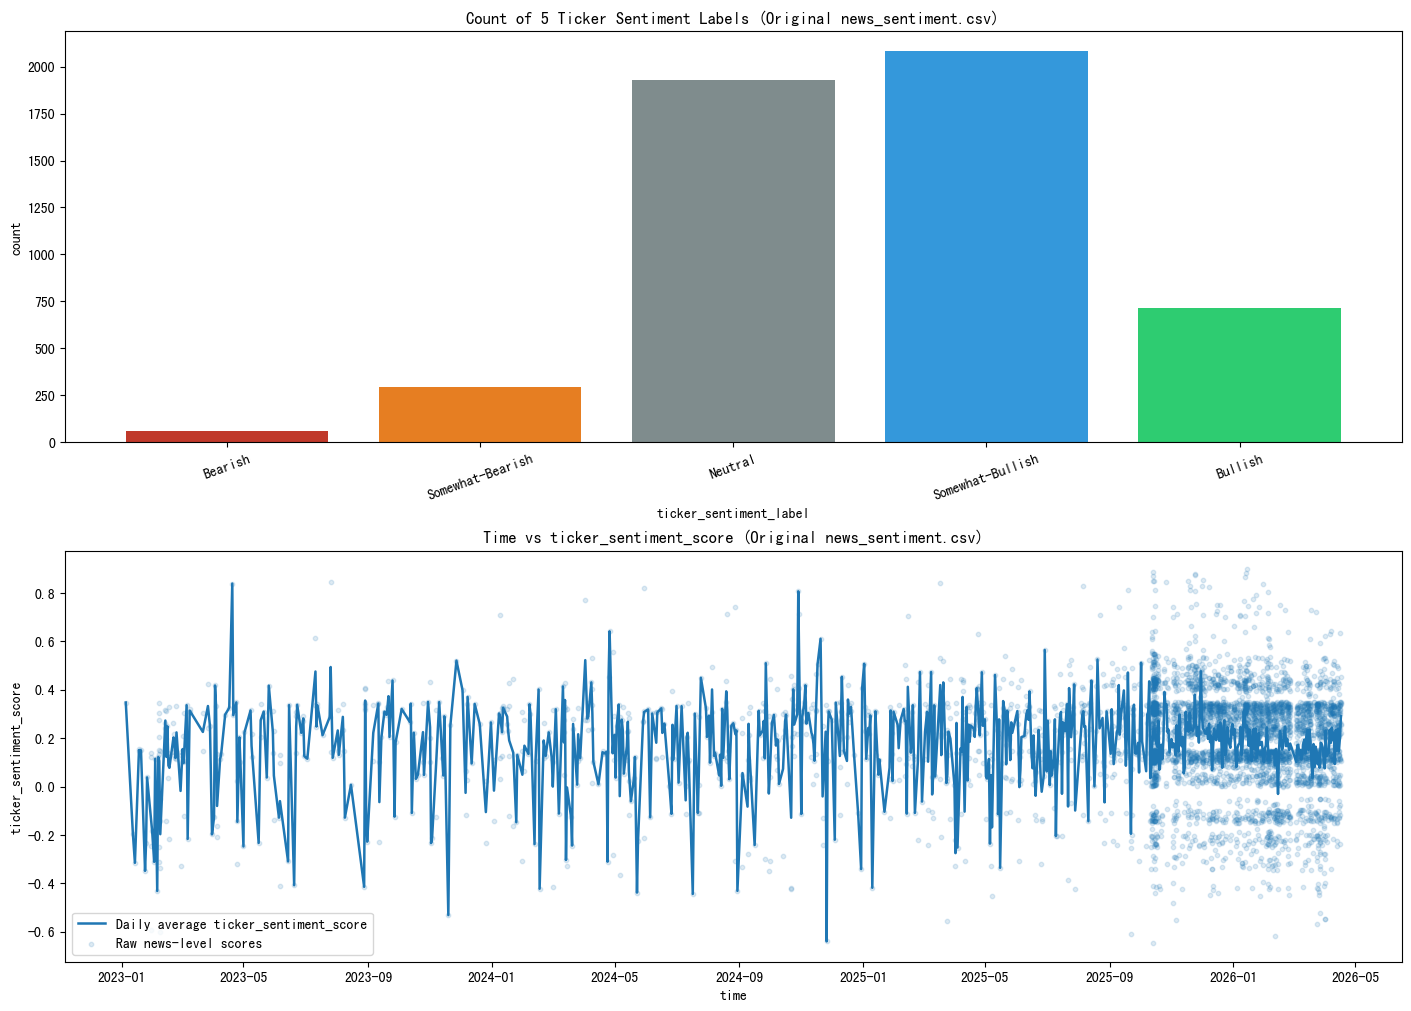

Rows used for visualization: 5,084
Label counts:


,ticker_sentiment_label,count
0,Bearish,60
1,Somewhat-Bearish,295
2,Neutral,1931
3,Somewhat-Bullish,2085
4,Bullish,713


In [152]:
import matplotlib.pyplot as plt
import pandas as pd

news_path = Path("../data/news_data/news_sentiment.csv")
viz_df = pd.read_csv(news_path)

viz_df["time_published"] = pd.to_datetime(viz_df["time_published"], errors="coerce")
viz_df["ticker_sentiment_score"] = pd.to_numeric(viz_df["ticker_sentiment_score"], errors="coerce")
viz_df = viz_df.dropna(subset=["time_published", "ticker_sentiment_label", "ticker_sentiment_score"]).copy()

label_order = [
    "Bearish",
    "Somewhat-Bearish",
    "Neutral",
    "Somewhat-Bullish",
    "Bullish",
]

label_counts = (
    viz_df["ticker_sentiment_label"]
    .value_counts()
    .reindex(label_order, fill_value=0)
    .rename_axis("ticker_sentiment_label")
    .reset_index(name="count")
)

daily_score = (
    viz_df.groupby(viz_df["time_published"].dt.normalize(), as_index=False)["ticker_sentiment_score"]
    .mean()
    .rename(columns={"time_published": "date", "ticker_sentiment_score": "avg_ticker_sentiment_score"})
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

axes[0].bar(
    label_counts["ticker_sentiment_label"],
    label_counts["count"],
    color=["#c0392b", "#e67e22", "#7f8c8d", "#3498db", "#2ecc71"],
)
axes[0].set_title("Count of 5 Ticker Sentiment Labels (Original news_sentiment.csv)")
axes[0].set_xlabel("ticker_sentiment_label")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)

axes[1].plot(
    daily_score["date"],
    daily_score["avg_ticker_sentiment_score"],
    color="#1f77b4",
    linewidth=1.8,
    label="Daily average ticker_sentiment_score",
)
axes[1].scatter(
    viz_df["time_published"],
    viz_df["ticker_sentiment_score"],
    alpha=0.15,
    s=10,
    color="#1f77b4",
    label="Raw news-level scores",
)
axes[1].set_title("Time vs ticker_sentiment_score (Original news_sentiment.csv)")
axes[1].set_xlabel("time")
axes[1].set_ylabel("ticker_sentiment_score")
axes[1].legend(loc="best")

plt.show()

print(f"Rows used for visualization: {len(viz_df):,}")
print("Label counts:")
display(label_counts)

Test metric comparison:


,model,accuracy,f1_weighted,f1_macro
0,News XGBoost,0.561602,0.541380,0.329703
1,News->Price XGBoost,0.422222,0.308668,0.144022


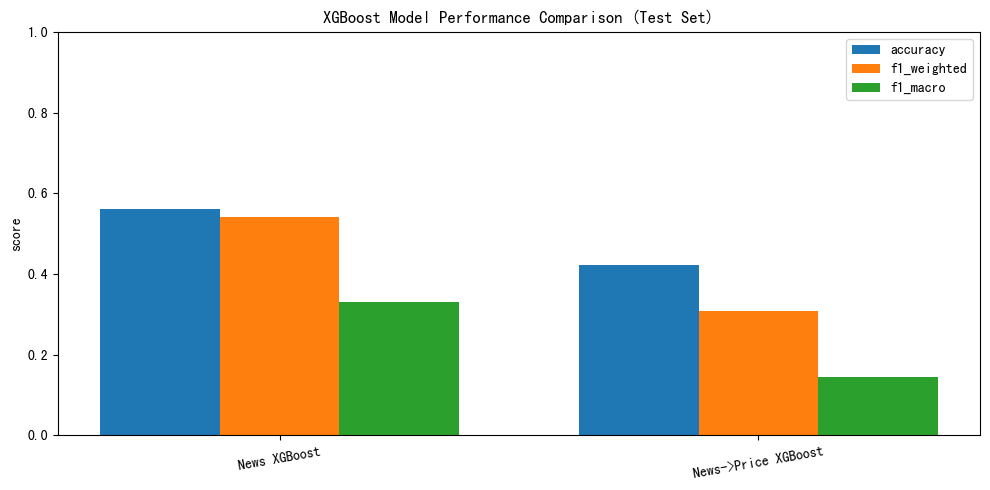

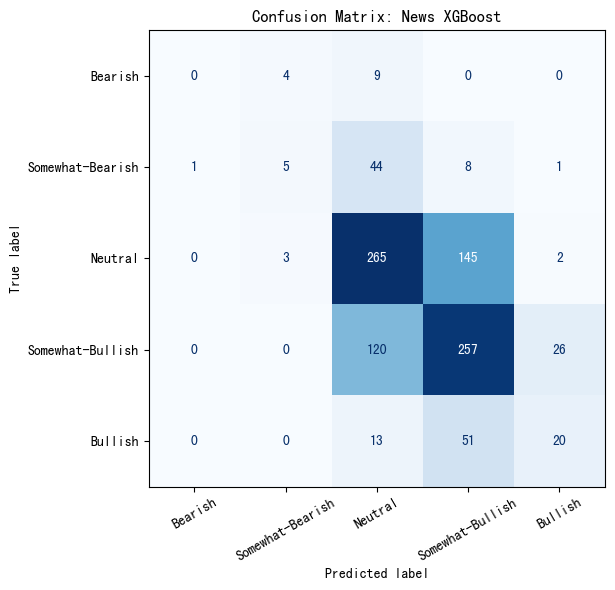

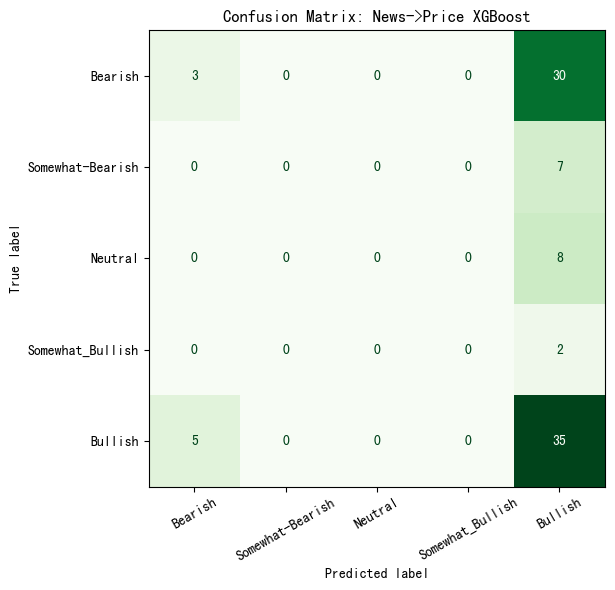

In [143]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score

# Ensure both model predictions exist from earlier cells.
required_vars = ["y_test", "test_predictions", "y_test_2", "test_pred_2"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise ValueError(
        f"Missing required variables: {missing_vars}. Run the XGBoost model cells first."
    )

# 1) Performance comparison (test set metrics).
news_metrics_row = {
    "model": "News XGBoost",
    "accuracy": accuracy_score(y_test, test_predictions),
    "f1_weighted": f1_score(y_test, test_predictions, average="weighted"),
    "f1_macro": f1_score(y_test, test_predictions, average="macro"),
}

news_to_price_metrics_row = {
    "model": "News->Price XGBoost",
    "accuracy": accuracy_score(y_test_2, test_pred_2),
    "f1_weighted": f1_score(y_test_2, test_pred_2, average="weighted"),
    "f1_macro": f1_score(y_test_2, test_pred_2, average="macro"),
}

comparison_df = pd.DataFrame([news_metrics_row, news_to_price_metrics_row])
print("Test metric comparison:")
display(comparison_df)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison_df))
bar_width = 0.25
ax.bar([i - bar_width for i in x], comparison_df["accuracy"], width=bar_width, label="accuracy")
ax.bar(x, comparison_df["f1_weighted"], width=bar_width, label="f1_weighted")
ax.bar([i + bar_width for i in x], comparison_df["f1_macro"], width=bar_width, label="f1_macro")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison_df["model"], rotation=10)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("XGBoost Model Performance Comparison (Test Set)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 2) Confusion matrices with ordered labels (Bearish -> Bullish) in two separate figures.
label_order_news = ["Bearish", "Somewhat-Bearish", "Neutral", "Somewhat-Bullish", "Bullish"]
label_order_price = ["Bearish", "Somewhat-Bearish", "Neutral", "Somewhat_Bullish", "Bullish"]

news_labels_present = set(y_test) | set(test_predictions)
news_labels = [label for label in label_order_news if label in news_labels_present]

news_to_price_labels_present = set(y_test_2) | set(test_pred_2)
news_to_price_labels = [label for label in label_order_price if label in news_to_price_labels_present]

cm_news = confusion_matrix(y_test, test_predictions, labels=news_labels)
cm_news_to_price = confusion_matrix(y_test_2, test_pred_2, labels=news_to_price_labels)

fig_news, ax_news = plt.subplots(figsize=(8, 6))
disp_news = ConfusionMatrixDisplay(confusion_matrix=cm_news, display_labels=news_labels)
disp_news.plot(ax=ax_news, cmap="Blues", colorbar=False, xticks_rotation=30)
ax_news.set_title("Confusion Matrix: News XGBoost")
plt.tight_layout()
plt.show()

fig_price, ax_price = plt.subplots(figsize=(8, 6))
disp_news_to_price = ConfusionMatrixDisplay(
    confusion_matrix=cm_news_to_price,
    display_labels=news_to_price_labels,
    )
disp_news_to_price.plot(ax=ax_price, cmap="Greens", colorbar=False, xticks_rotation=30)
ax_price.set_title("Confusion Matrix: News->Price XGBoost")
plt.tight_layout()
plt.show()